# Hilbert Phase Tester

## What this notebook does

Validates a **per-frame, per-leg gait phase** approach based on the Hilbert transform of leg-tip 3D speed, on two data types:

- **Part A — Walking** (`.h5` with IK joint angles + world keypoints)
- **Part B — Amputee coordination** (JARVIS CSV, 3D keypoints only)

---

## Pipeline: step by step

### 1. Load leg-tip XYZ positions
- **Walking**: `xpos` from HDF5 (stac-mjx output), world-frame, shape `(T, N_bodies, 3)`. Claw body names used to index each leg tip.
- **Amputee**: JARVIS `data3D.csv` — flat columns, positional extraction (`col idx, idx+1, idx+2`), divided by 10 to get mm. A user-specified frame window selects the bout.

---

### 2. `compute_hilbert_phase_bout` → phase + speed per leg

Applied independently to each leg tip:

```
XYZ (T,3)
  │
  ├─ NaN fill (linear interp per dimension)
  │
  ├─ np.gradient × fps  →  velocity (T,3)   [mm/s]
  │
  ├─ ‖velocity‖         →  speed (T,)        [mm/s, always ≥ 0]
  │
  ├─ gaussian_filter1d(σ)  →  smoothed speed   [one pass only]
  │
  ├─ speed − mean(speed)   →  centered speed   [oscillates around 0 → phase spans full ±π]
  │
  └─ angle(hilbert( · ))  →  phase (T,) ∈ [−π, π]
         phase = 0   : speed peak      = mid-swing
         phase = ±π  : speed trough    = mid-stance
         first/last 2 frames → NaN (edge artifact)
```

Optional **stance masking** (`MASK_STANCE=True`): frames where `speed < frac × max` → `phase = NaN`.
⚠️ Use masked phase for *visualization only*. For inter-leg phase differences use the **unmasked** version — alternating legs are in stance during each other's swing, so masking both creates all-NaN overlaps.

---

### 3. Cell 4 — Diagnostic: speed + phase overlay
Speed (blue, left axis) and phase (orange, right axis) on the same time axis per leg.
**What to verify**: the orange sawtooth is locked to the blue speed bursts — each peak aligns with phase = 0.

---

### 4. Cells 5–6 — Phase-based resampling (walking)

Reference leg: **T1L** (walking) or **T1R** (amputee, T1L is amputated).

```
ref phase (unmasked, T1L)
  │
  ├─ unwrap + detect 2π increments  →  step-cycle onset frames
  │
  └─ for each cycle [t0 → t1]:
       seg_phase = ref_phase[t0:t1] + π   →  [0, 2π]
       for each signal (joint angle, tip Z, …):
         np.interp(phase_grid, seg_phase, values, period=2π)
         →  signal resampled onto uniform phase grid (100 bins)
```

Average across cycles → mean ± std trajectory as a function of **Hilbert phase**.
Gait events (liftoff, touchdown) detected from speed threshold crossings and marked as vertical lines.

---

### 5. Cell 6b / 8b — Z-tip vs phase scatter (validation)
World-frame Z of each leg tip, colored by Hilbert phase (`twilight` colormap).
**What to verify**: high Z → phase ≈ 0 (mid-swing, orange/yellow), low Z → phase ≈ ±π (mid-stance, blue/purple). Gray dots = stance-masked frames.

---

### 6. Cell 8 — Inter-leg phase coordination (amputee)

```
phase_A (T1R, unmasked)
phase_B (other leg, unmasked)
  │
  └─ diff = (phase_A − phase_B + π) mod 2π − π   →  wrapped to [−π, π]
       histogram → mean resultant length R = |mean(exp(i·diff))|
         R = 1 : perfectly consistent phase relationship
         R = 0 : no coordination
```

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter1d
import sys, pathlib

sys.path.insert(0, str(pathlib.Path('../utils')))
import io_dict_to_hdf5 as h5io

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## Cell 1 — Configuration
Fill in `h5_path` and `csv_path` before running.

In [43]:
CFG = dict(
    # ── Walking data (IK output, .h5) ──────────────────────────────────
    h5_path          = pathlib.Path('/home/user/src/JARVIS-HybridNet/projects/fly50_V5_male/predictions/predictions3D/Predictions_3D_20260123-093310/ik_output_v1_courtship.h5'),   # ← fill in
    bout_id          =  'bout_003',                  # None = pick first available
    ref_leg_walk     = 'T1_left',

    # ── Amputee data (JARVIS data3D.csv) ───────────────────────────────
    csv_path         = pathlib.Path('/home/user/src/JARVIS-HybridNet/projects/fly44_l_V4/predictions/predictions3D/Predictions_3D_20260228-210401/data3D.csv'),   # ← fill in
    frame_start      = 78699,
    frame_end        = 80557,
    ref_leg_amput    = 'T1_right',            # T1L is amputated

    # ── Hilbert params ─────────────────────────────────────────────────
    fps              = 800,                   # ← adjust to your data
    smooth_sigma     = 6,                     # Gaussian σ in frames (single smoothing pass)
    MASK_STANCE      = True,                  # set stance-period phase to NaN
    stance_speed_frac= 0.20,                  # fraction of max speed → stance threshold

    # ── Resampling ─────────────────────────────────────────────────────
    n_phase_bins     = 100,
)

LEGS_WALK  = ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']
LEGS_AMPUT = ['T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']  # T1L absent

# Leg tip claw names in MuJoCo xpos (walking data)
CLAW_NAMES = {
    'T1_left':  'claw_T1_left',
    'T1_right': 'claw_T1_right',
    'T2_left':  'claw_T2_left',
    'T2_right': 'claw_T2_right',
    'T3_left':  'claw_T3_left',
    'T3_right': 'claw_T3_right',
}

PHASE_PAIRS = [
    ('T1_left',  'T1_right'),
    ('T2_left',  'T2_right'),
    ('T3_left',  'T3_right'),
]

print('Config set.')

Config set.


## Cell 2 — Core function: `compute_hilbert_phase_bout`

In [44]:
def compute_hilbert_phase_bout(positions_xyz, fps, smooth_sigma,
                               mask_stance=False, stance_speed_frac=0.20):
    """
    Per-frame Hilbert phase from 3D tip speed (single smoothing pass).

    Speed is mean-centered before Hilbert so the phase spans the full [-π, π]:
      phase = 0  → mid-swing (peak speed)
      phase = ±π → mid-stance (speed trough)

    Parameters
    ----------
    positions_xyz     : (T, 3) float array  — world-frame XYZ of one leg tip
    fps               : float               — frames per second
    smooth_sigma      : float               — Gaussian σ (frames) applied to raw speed
    mask_stance       : bool                — if True, stance frames → phase = NaN
    stance_speed_frac : float               — speed < frac*max → stance

    Returns
    -------
    phase : (T,) float  — instantaneous phase in [-π, π];
                          NaN at first/last 2 frames and (optionally) stance
    speed : (T,) float  — smoothed 3D speed (mm/s), NOT mean-subtracted
    """
    T = len(positions_xyz)
    if T < 10:
        return np.full(T, np.nan), np.zeros(T)

    # Fill NaNs via linear interpolation before computing gradient
    xyz = positions_xyz.astype(float).copy()
    for dim in range(3):
        col = xyz[:, dim]
        nans = np.isnan(col)
        if nans.any() and (~nans).sum() > 1:
            col[nans] = np.interp(np.flatnonzero(nans), np.flatnonzero(~nans), col[~nans])
        xyz[:, dim] = col

    # 1. Raw 3D speed (mm/s)
    vel     = np.gradient(xyz, axis=0) * fps   # (T, 3)
    spd_raw = np.linalg.norm(vel, axis=1)       # (T,) — always ≥ 0

    # 2. Smooth once
    spd = gaussian_filter1d(spd_raw, sigma=smooth_sigma)

    # 3. Mean-center so the signal oscillates around zero → phase spans full [-π, π]
    spd_centered = spd - np.nanmean(spd)

    # 4. Hilbert phase  →  [-π, π]
    ph = np.angle(hilbert(spd_centered))
    ph[:2]  = np.nan
    ph[-2:] = np.nan

    # 5. Optional stance masking (uses original speed for threshold)
    if mask_stance:
        thr = stance_speed_frac * np.nanmax(spd)
        ph[spd <= thr] = np.nan

    return ph, spd   # return original (non-centered) speed for plotting/thresholding


def swing_onsets_from_hilbert(phase):
    """
    Find swing onset indices from Hilbert phase by detecting each 2π increment
    in the unwrapped phase (= start of a new step cycle).
    """
    finite_mask = np.isfinite(phase)
    if finite_mask.sum() < 4:
        return np.array([], dtype=int)
    finite_idx  = np.where(finite_mask)[0]
    ph_finite   = phase[finite_mask]
    unwrapped   = np.unwrap(ph_finite)
    cycle_floor = np.floor(unwrapped / (2 * np.pi))
    jumps       = np.where(np.diff(cycle_floor) > 0)[0]
    return finite_idx[jumps]


print('Core functions defined.')

Core functions defined.


---
# Part A — Walking data

In [45]:
# Load .h5
data = h5io.load(str(CFG['h5_path']), enable_jax=False)
bout_keys = list(data.keys())
bid = CFG['bout_id'] if CFG['bout_id'] is not None else bout_keys[0]
bout = data[bid]
print(f"Using bout: '{bid}'  |  available keys: {list(bout.keys())}")

# World-frame body positions
xpos  = np.array(bout['xpos'])        # (T, N_bodies, 3)
names = list(data['info']['names_xpos'])      # adjust key name if needed
T_walk = xpos.shape[0]
print(f"xpos shape: {xpos.shape}")
print(f"Body names (first 20): {names[:20]}")

# Compute Hilbert phase for each leg
phase_walk = {}
speed_walk = {}
for leg, claw in CLAW_NAMES.items():
    if claw not in names:
        print(f'  Warning: {claw} not found in xpos_names — skipping {leg}')
        continue
    idx = names.index(claw)
    xyz = xpos[:, idx, :]             # (T, 3)
    ph, spd = compute_hilbert_phase_bout(
        xyz, CFG['fps'], CFG['smooth_sigma'],
        mask_stance=CFG['MASK_STANCE'],
        stance_speed_frac=CFG['stance_speed_frac'])
    phase_walk[leg] = ph
    speed_walk[leg] = spd

print(f"\nPhase computed for: {list(phase_walk.keys())}")

Using bout: 'bout_003'  |  available keys: ['geometric_angles', 'kp_data', 'marker_sites', 'qpos', 'qpos_stac', 'qvel', 'xpos', 'xpos_egocentric', 'xpos_stac', 'xquat', 'xquat_stac']
xpos shape: (2287, 68, 3)
Body names (first 20): ['world', 'thorax', 'head', 'rostrum', 'haustellum', 'labrum_left', 'labrum_right', 'antenna_left', 'antenna_right', 'wing_left', 'wing_right', 'abdomen', 'abdomen_2', 'abdomen_3', 'abdomen_4', 'abdomen_5', 'abdomen_6', 'abdomen_7', 'haltere_left', 'haltere_right']

Phase computed for: ['T1_left', 'T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']


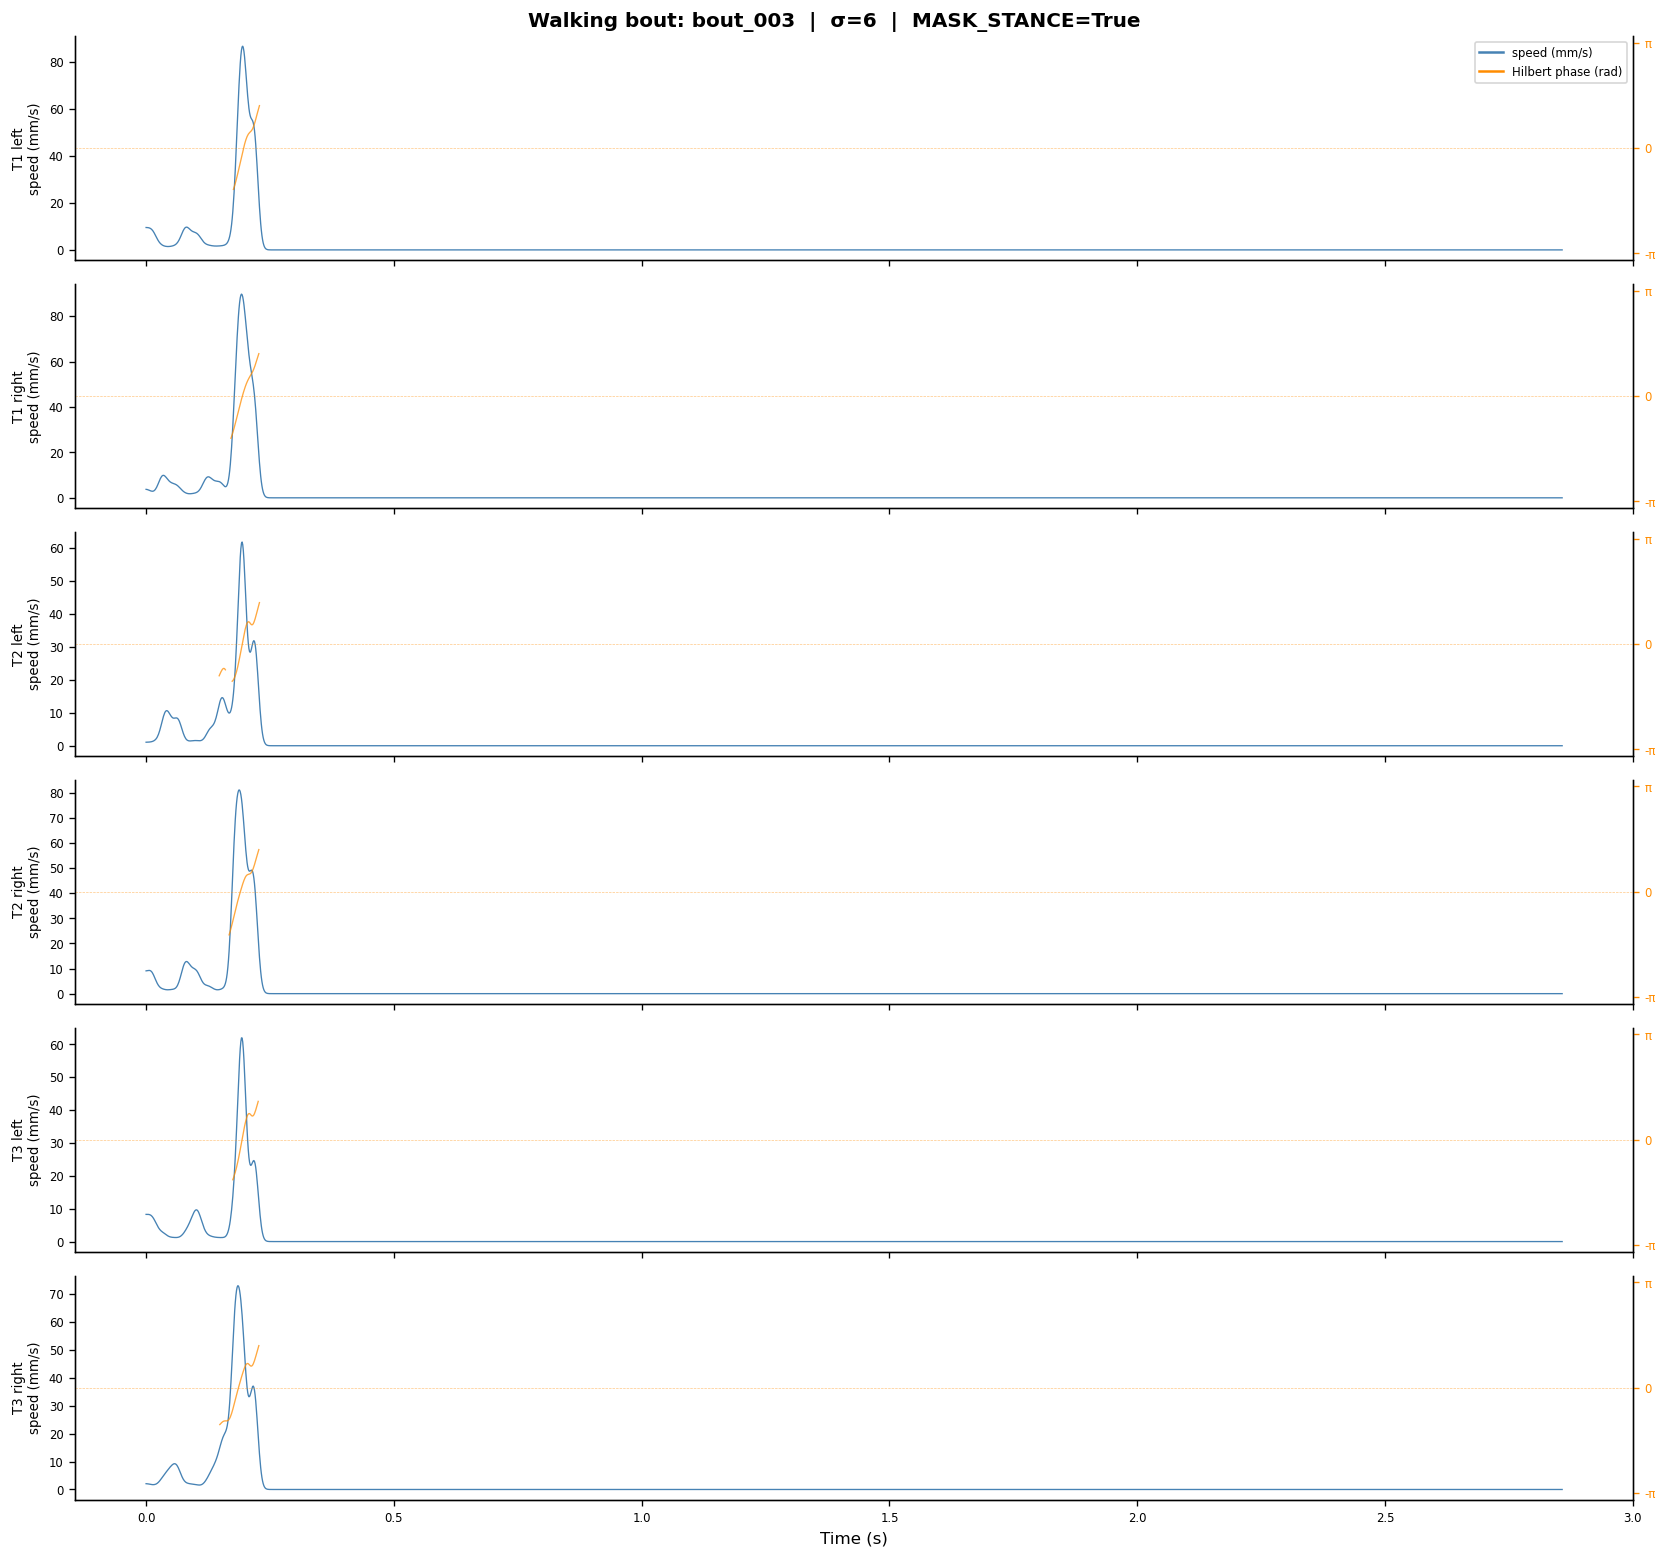

In [46]:
# Cell 4 — Speed + phase diagnostic (walking): phase overlaid on speed
legs_present = [l for l in LEGS_WALK if l in phase_walk]
t_walk = np.arange(T_walk) / CFG['fps']

fig, axes = plt.subplots(len(legs_present), 1,
                          figsize=(14, 2.2 * len(legs_present)), sharex=True)
if len(legs_present) == 1:
    axes = [axes]

for i, leg in enumerate(legs_present):
    ph  = phase_walk[leg]
    spd = speed_walk[leg]

    ax_s = axes[i]
    ax_s.plot(t_walk, spd, lw=0.8, color='steelblue', label='speed')
    ax_s.set_ylabel(leg.replace('_', ' ') + '\nspeed (mm/s)', fontsize=8)
    ax_s.spines[['top']].set_visible(False)
    ax_s.tick_params(labelsize=7)

    ax_p = ax_s.twinx()
    ax_p.plot(t_walk, ph, lw=0.8, color='darkorange', alpha=0.75, label='phase')
    ax_p.set_ylim(-np.pi - 0.2, np.pi + 0.2)
    ax_p.set_yticks([-np.pi, 0, np.pi])
    ax_p.set_yticklabels(['-π', '0', 'π'], fontsize=7, color='darkorange')
    ax_p.axhline(0, color='darkorange', lw=0.4, ls='--', alpha=0.5)
    ax_p.spines[['top']].set_visible(False)
    ax_p.tick_params(axis='y', colors='darkorange', labelsize=7)

    if i == 0:
        lines = [plt.Line2D([0], [0], color='steelblue', lw=1.5),
                 plt.Line2D([0], [0], color='darkorange', lw=1.5)]
        ax_s.legend(lines, ['speed (mm/s)', 'Hilbert phase (rad)'],
                    fontsize=7, loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.suptitle(f"Walking bout: {bid}  |  σ={CFG['smooth_sigma']}  |  MASK_STANCE={CFG['MASK_STANCE']}",
             fontweight='bold')
plt.tight_layout()
plt.show()

In [47]:
# Cell 5 — Phase-based resampling (walking, all joints)
qpos   = np.array(bout['qpos'])       # (T, n_joints)
jnames = list(data['info']['names_qpos'])     # adjust key if needed

ref_leg         = CFG['ref_leg_walk']
ref_phase       = phase_walk[ref_leg]
ref_phase_shift = ref_phase + np.pi   # → [0, 2π]

phase_grid = np.linspace(0, 2 * np.pi, CFG['n_phase_bins'], endpoint=False)

onsets = swing_onsets_from_hilbert(ref_phase)
print(f"Detected {len(onsets)} step cycles for reference leg '{ref_leg}'")

resampled_walk = {}   # joint_name → (n_cycles, n_phase_bins)
for j, jname in enumerate(jnames):
    traces = []
    for i in range(len(onsets) - 1):
        t0, t1 = int(onsets[i]), int(onsets[i + 1])
        seg_phase = ref_phase_shift[t0:t1]
        seg_vals  = qpos[t0:t1, j].astype(float)
        valid = np.isfinite(seg_phase) & np.isfinite(seg_vals)
        if valid.sum() < 5:
            continue
        traces.append(np.interp(phase_grid, seg_phase[valid], seg_vals[valid],
                                period=2 * np.pi))
    if traces:
        resampled_walk[jname] = np.array(traces)

print(f"Resampled {len(resampled_walk)} joints across {len(onsets) - 1} cycles")

Detected 1 step cycles for reference leg 'T1_left'
Resampled 0 joints across 0 cycles


Liftoff at Hilbert phase: -70.7°  |  touchdown at: 75.9°  (0° = mid-swing)


/tmp/ipykernel_3132292/2900806165.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=6, loc='upper right')


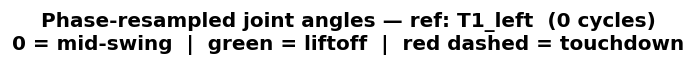

In [48]:
# Cell 6 — Phase-resampled joint averages (walking)
# X-axis: Hilbert phase [−π, π]  |  0 = mid-swing (peak speed)
# Green line = liftoff (speed crosses threshold going up,   ≈ −π/2)
# Red dashed = touchdown (speed crosses threshold going down, ≈ +π/2)
# Y-axis: joint angle in degrees.

# Unmasked reference phase for event detection
_ref_idx = names.index(CLAW_NAMES[ref_leg])
_ref_phase_raw, _spd = compute_hilbert_phase_bout(
    xpos[:, _ref_idx, :], CFG['fps'], CFG['smooth_sigma'], mask_stance=False)

_thr   = CFG['stance_speed_frac'] * np.nanmax(_spd)
_above = (_spd > _thr).astype(int)
_liftoff_frames   = np.where(np.diff(_above) ==  1)[0] + 1   # first swing frame
_touchdown_frames = np.where(np.diff(_above) == -1)[0] + 1   # first stance frame

def _mean_phase_at(frames, phase_arr):
    idx = frames[frames < len(phase_arr)]
    ph  = phase_arr[idx]
    ph  = ph[np.isfinite(ph)]
    return float(np.angle(np.mean(np.exp(1j * ph)))) if len(ph) else None

_liftoff_orig   = _mean_phase_at(_liftoff_frames,   _ref_phase_raw)
_touchdown_orig = _mean_phase_at(_touchdown_frames, _ref_phase_raw)

lo_deg = f"{np.degrees(_liftoff_orig):.1f}°"   if _liftoff_orig   is not None else "n/a"
td_deg = f"{np.degrees(_touchdown_orig):.1f}°" if _touchdown_orig is not None else "n/a"
print(f"Liftoff at Hilbert phase: {lo_deg}  |  touchdown at: {td_deg}  (0° = mid-swing)")

# Phase display axis: phase_grid [0, 2π] → Hilbert phase [−π, +π]
phase_display = phase_grid - np.pi

# ── Plot ─────────────────────────────────────────────────────────────────────
joints_to_plot = [j for j in jnames if ref_leg in j][:12]
n_j   = len(joints_to_plot)
ncols = 4
nrows = int(np.ceil(n_j / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.5 * nrows), sharey=False)
axes = np.array(axes).flatten()

for ax, jname in zip(axes, joints_to_plot):
    if jname not in resampled_walk:
        ax.set_visible(False)
        continue
    mat  = resampled_walk[jname]
    mean = np.degrees(np.nanmean(mat, axis=0))
    std  = np.degrees(np.nanstd(mat,  axis=0))

    ax.fill_between(phase_display, mean - std, mean + std, alpha=0.25, color='steelblue')
    ax.plot(phase_display, mean, color='steelblue', lw=1.5)
    ax.axvline(0, color='k', ls=':', lw=0.8, alpha=0.5)
    if _liftoff_orig is not None:
        ax.axvline(_liftoff_orig,   color='#2ca02c', ls='-',  lw=1.2, label='liftoff')
    if _touchdown_orig is not None:
        ax.axvline(_touchdown_orig, color='#d62728', ls='--', lw=1.2, label='touchdown')

    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'], fontsize=6)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylabel('Joint angle (°)', fontsize=7)
    ax.set_title(jname, fontsize=7)
    ax.tick_params(labelsize=7)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend(fontsize=6, loc='upper right')
for ax in axes[n_j:]:
    ax.set_visible(False)

plt.suptitle(
    f'Phase-resampled joint angles — ref: {ref_leg}  ({len(onsets)-1} cycles)\n'
    f'0 = mid-swing  |  green = liftoff  |  red dashed = touchdown',
    fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3132292/994259364.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


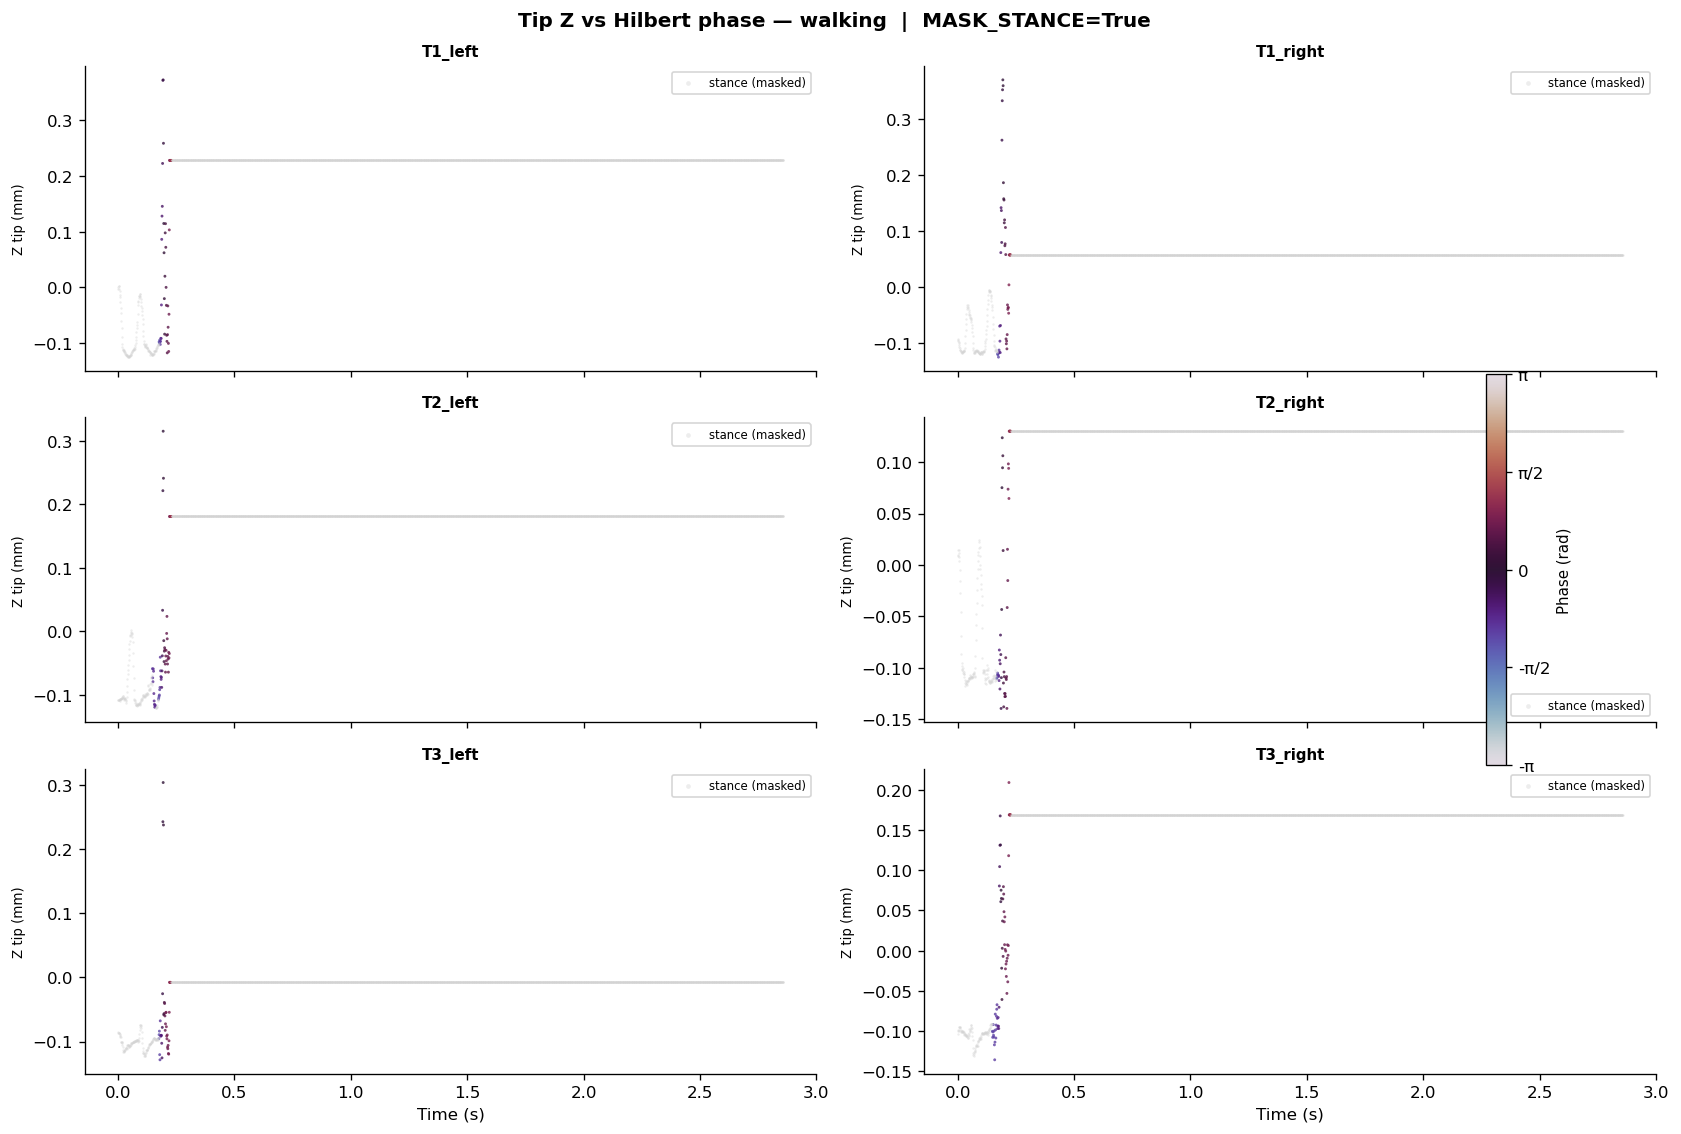

In [49]:
# Cell 6b — Tip Z vs Hilbert phase validation (walking)
# Rows: T1L/T1R, T2L/T2R, T3L/T3R — colored by phase (twilight)
norm   = Normalize(-np.pi, np.pi)
t_walk = np.arange(T_walk) / CFG['fps']

fig, axes = plt.subplots(len(PHASE_PAIRS), 2,
                          figsize=(14, 3.2 * len(PHASE_PAIRS)), sharex=True)

for row, (leg_l, leg_r) in enumerate(PHASE_PAIRS):
    for col, leg in enumerate([leg_l, leg_r]):
        ax = axes[row, col]
        claw = CLAW_NAMES.get(leg, '')

        if claw not in names or leg not in phase_walk:
            ax.text(0.5, 0.5, 'Not found', ha='center', va='center',
                    transform=ax.transAxes, color='gray', fontsize=10)
            ax.set_title(leg, fontsize=9, fontweight='bold')
            continue

        idx = names.index(claw)
        z   = xpos[:, idx, 2]          # world-frame Z of tip
        ph  = phase_walk[leg]

        valid = np.isfinite(ph)
        sc = ax.scatter(t_walk[valid], z[valid], c=ph[valid], cmap='twilight',
                        norm=norm, s=3, alpha=0.8, linewidths=0)
        if (~valid).any():
            ax.scatter(t_walk[~valid], z[~valid], color='lightgray',
                       s=2, alpha=0.4, linewidths=0, label='stance (masked)')

        ax.set_ylabel('Z tip (mm)', fontsize=8)
        ax.set_title(leg, fontsize=9, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)
        if (~valid).any():
            ax.legend(fontsize=7, markerscale=2)

sm = ScalarMappable(cmap='twilight', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('Phase (rad)', fontsize=9)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
plt.suptitle(
    f'Tip Z vs Hilbert phase — walking  |  MASK_STANCE={CFG["MASK_STANCE"]}',
    fontweight='bold')
plt.tight_layout()
plt.show()

Short (1): [2287] frames
Long  (1): [2287] frames


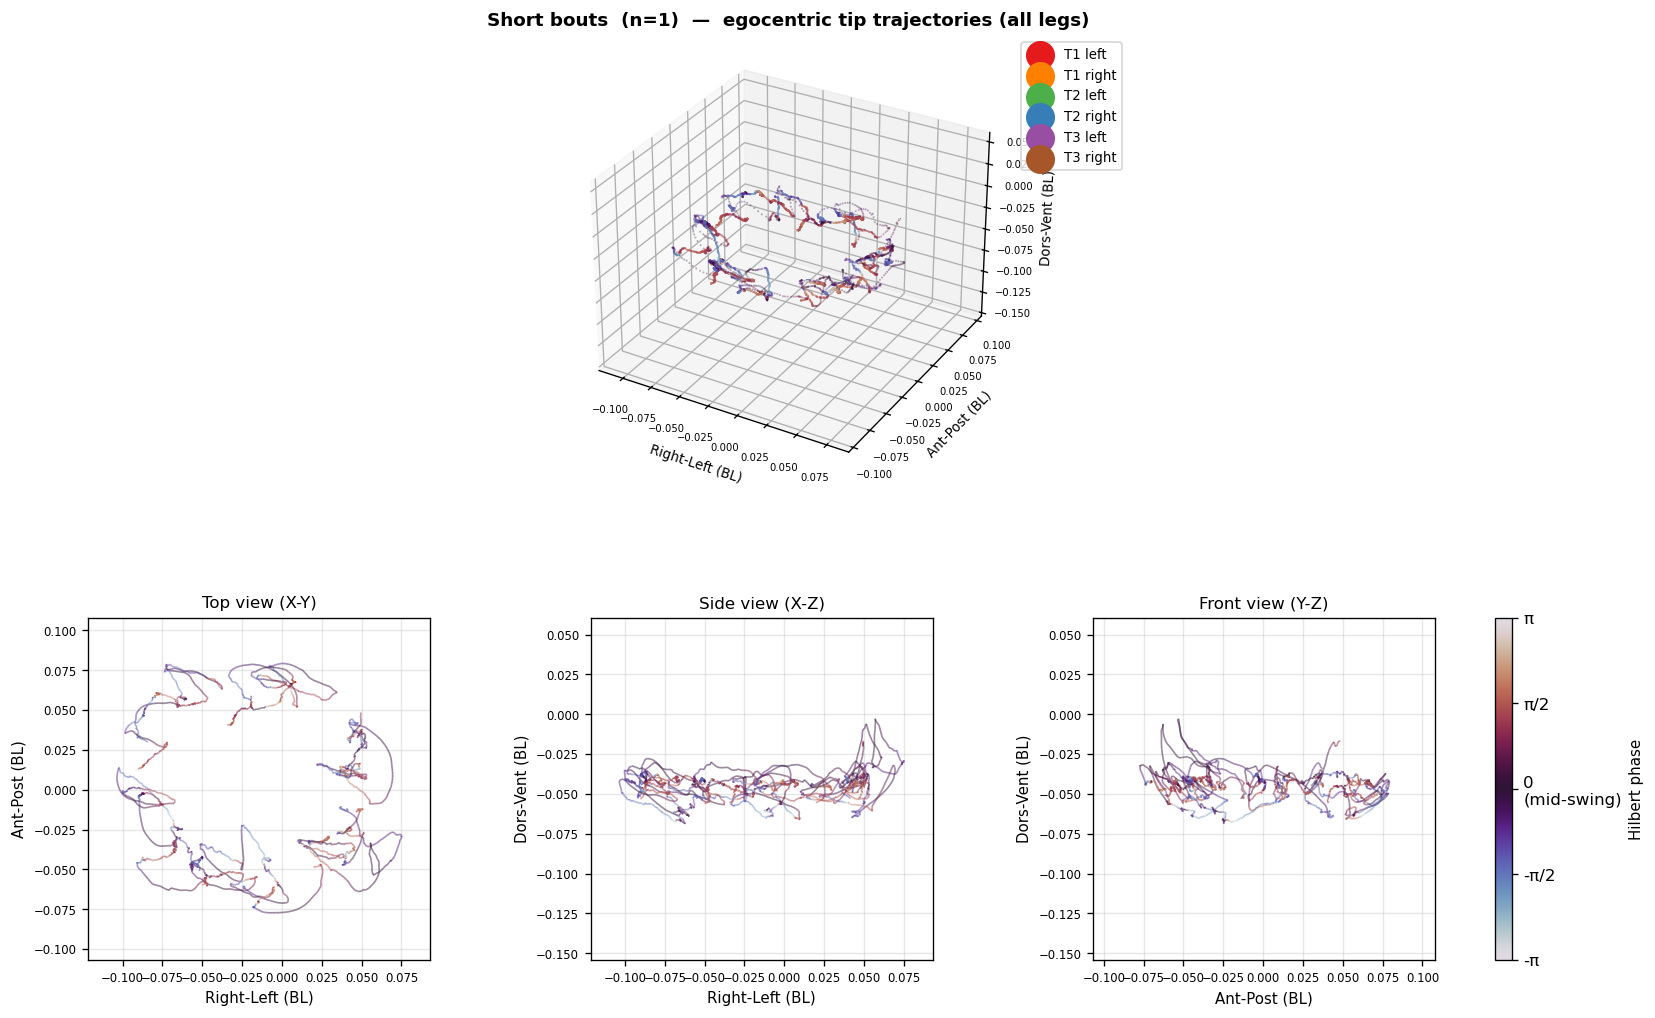

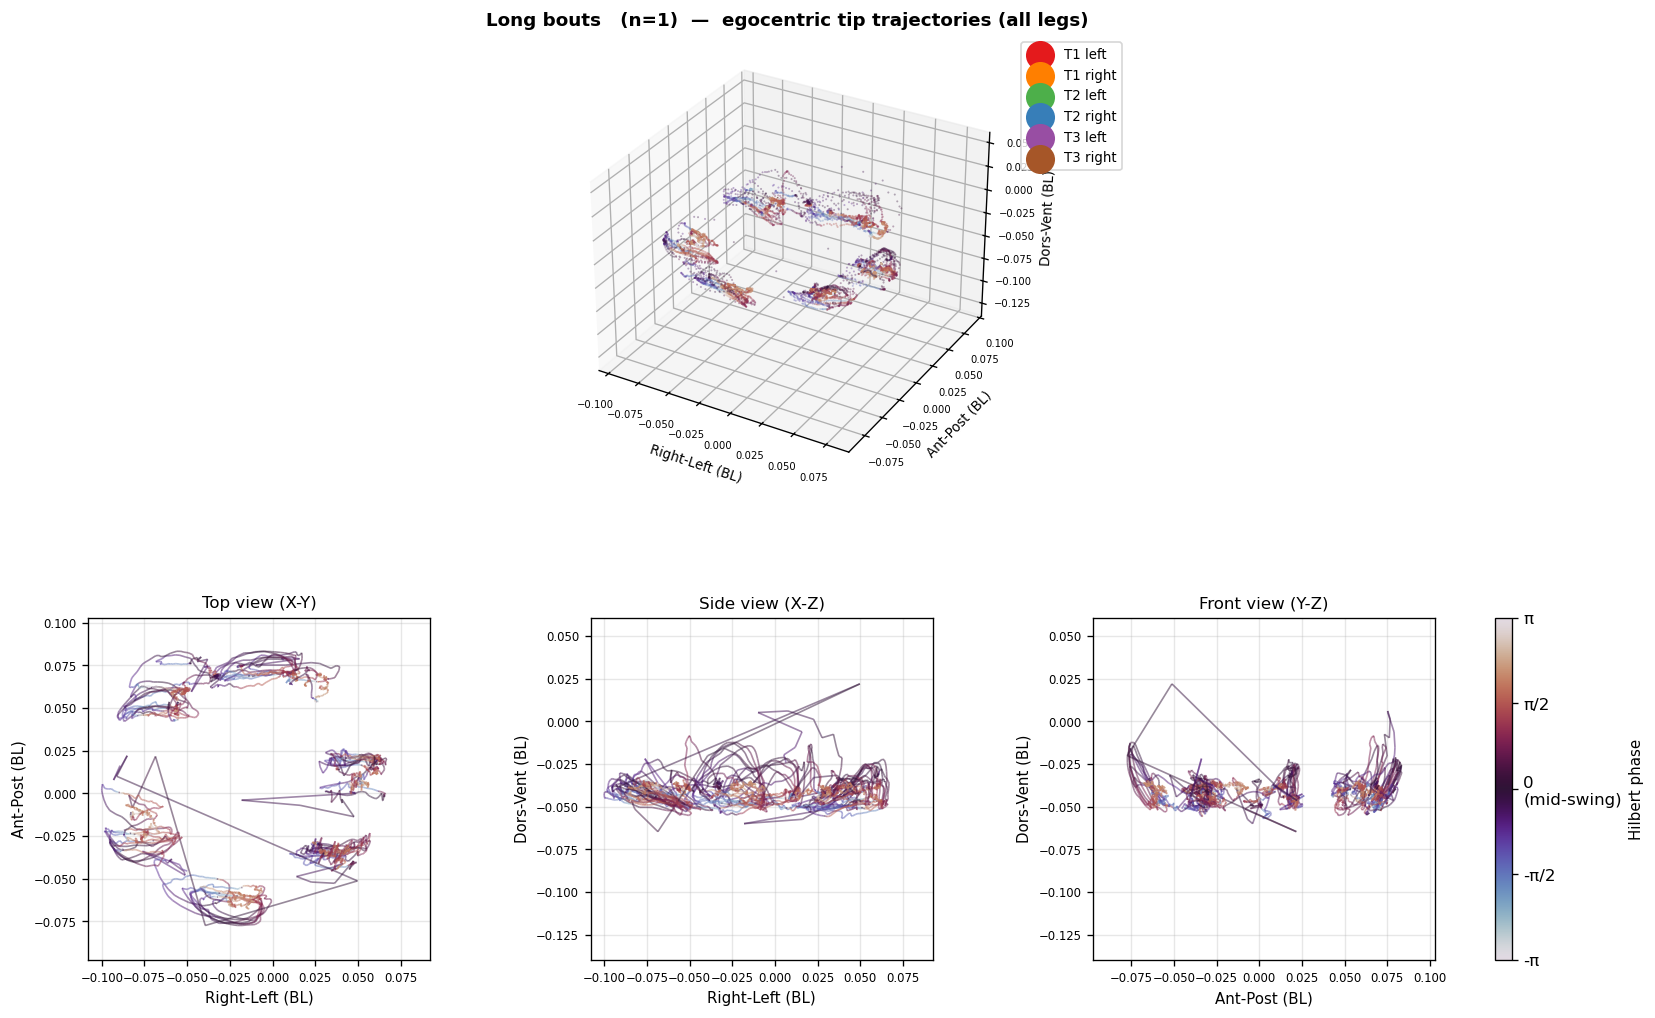

In [50]:
# Cell 6c — Egocentric leg-tip trajectories: 3D + 2D projections, colored by Hilbert phase
# Layout: 3D (top) + Top/Side/Front projections (bottom)
# Color: Hilbert phase (twilight, −π to π)  |  Axes: body-length normalized
# Egocentric = xpos of leg tip minus xpos of thorax (same name list, no index mismatch)
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import LineCollection

BODY_LENGTH_MM = 2.5   # ← adjust to your fly (mm)

LEG_COLORS = {
    'T1_left':  '#e41a1c', 'T1_right': '#ff7f00',
    'T2_left':  '#4daf4a', 'T2_right': '#377eb8',
    'T3_left':  '#984ea3', 'T3_right': '#a65628',
}

thorax_idx = names.index('thorax')   # reference origin for egocentric

# ── Select bouts ──────────────────────────────────────────────────────────────
valid_bouts  = [k for k in data.keys() if isinstance(data[k], dict) and 'xpos' in data[k]]
bout_lengths = {k: np.array(data[k]['xpos']).shape[0] for k in valid_bouts}
sorted_bouts = sorted(bout_lengths.items(), key=lambda x: x[1])
n_sel        = min(1, len(sorted_bouts) // 2)
short_bouts  = [b[0] for b in sorted_bouts[:n_sel]]
long_bouts   = [b[0] for b in sorted_bouts[-n_sel:]]
print(f"Short ({n_sel}): {[bout_lengths[b] for b in short_bouts]} frames")
print(f"Long  ({n_sel}): {[bout_lengths[b] for b in long_bouts]} frames")

# ── Helper ────────────────────────────────────────────────────────────────────
def collect_leg_trajs(group_bouts, claw_name):
    out = []
    for bid_g in group_bouts:
        xpos_b   = np.array(data[bid_g]['xpos'])          # (T, 68, 3)
        claw_idx = names.index(claw_name)
        xyz_raw  = xpos_b[:, claw_idx, :] - xpos_b[:, thorax_idx, :]   # egocentric
        xyz_bl   = xyz_raw / BODY_LENGTH_MM
        ph, _    = compute_hilbert_phase_bout(
            xpos_b[:, claw_idx, :], CFG['fps'], CFG['smooth_sigma'], mask_stance=False)
        valid = np.isfinite(ph) & np.isfinite(xyz_bl).all(axis=1)
        if valid.sum() < 10:
            continue
        out.append((xyz_bl, ph, valid))
    return out

# ── Figure factory ────────────────────────────────────────────────────────────
def make_traj_figure(group_name, group_bouts):
    fig = plt.figure(figsize=(16, 10))
    gs  = fig.add_gridspec(2, 3, height_ratios=[1.3, 1], hspace=0.35, wspace=0.3)
    ax3d  = fig.add_subplot(gs[0, :], projection='3d')
    ax_xy = fig.add_subplot(gs[1, 0])
    ax_xz = fig.add_subplot(gs[1, 1])
    ax_yz = fig.add_subplot(gs[1, 2])

    norm    = Normalize(-np.pi, np.pi)
    all_pts = []

    for leg in LEGS_WALK:
        trajs = collect_leg_trajs(group_bouts, CLAW_NAMES[leg])
        for xyz, ph, valid in trajs:
            x, y, z = xyz[valid, 0], xyz[valid, 1], xyz[valid, 2]
            p = ph[valid]
            all_pts.append(xyz[valid])

            ax3d.scatter(x, y, z, c=p, cmap='twilight', norm=norm,
                         s=1.5, alpha=0.35, linewidths=0)

            for ax, xi, yi in [(ax_xy, 0, 1), (ax_xz, 0, 2), (ax_yz, 1, 2)]:
                pts  = np.column_stack([xyz[valid, xi], xyz[valid, yi]])
                segs = np.stack([pts[:-1], pts[1:]], axis=1)
                lc   = LineCollection(segs, cmap='twilight', norm=norm,
                                      linewidths=1.0, alpha=0.5)
                lc.set_array((p[:-1] + p[1:]) / 2)
                ax.add_collection(lc)

        ax3d.scatter([], [], [], c=LEG_COLORS[leg], s=30,
                     label=leg.replace('_', ' '))

    # Equal axis limits
    if all_pts:
        pts = np.vstack(all_pts)
        mid = np.nanmean(pts, axis=0)
        rng = np.nanmax(np.ptp(pts, axis=0)) / 2 * 1.2

        ax3d.set_xlim(mid[0]-rng, mid[0]+rng)
        ax3d.set_ylim(mid[1]-rng, mid[1]+rng)
        ax3d.set_zlim(mid[2]-rng, mid[2]+rng)

        for ax, xi, yi in [(ax_xy, 0, 1), (ax_xz, 0, 2), (ax_yz, 1, 2)]:
            ax.set_xlim(mid[xi]-rng, mid[xi]+rng)
            ax.set_ylim(mid[yi]-rng, mid[yi]+rng)
            ax.autoscale(False)
            ax.set_aspect('equal')

    ax3d.set_xlabel('Right-Left (BL)', fontsize=8, labelpad=2)
    ax3d.set_ylabel('Ant-Post (BL)',   fontsize=8, labelpad=2)
    ax3d.set_zlabel('Dors-Vent (BL)',  fontsize=8, labelpad=2)
    ax3d.tick_params(labelsize=6)
    ax3d.set_title(f'{group_name}  —  egocentric tip trajectories (all legs)',
                   fontsize=11, fontweight='bold')
    ax3d.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8,
                markerscale=3, framealpha=0.8)

    for ax, xl, yl, ttl in [
        (ax_xy, 'Right-Left (BL)', 'Ant-Post (BL)',  'Top view (X-Y)'),
        (ax_xz, 'Right-Left (BL)', 'Dors-Vent (BL)', 'Side view (X-Z)'),
        (ax_yz, 'Ant-Post (BL)',   'Dors-Vent (BL)', 'Front view (Y-Z)'),
    ]:
        ax.set_xlabel(xl, fontsize=9);  ax.set_ylabel(yl, fontsize=9)
        ax.set_title(ttl, fontsize=10); ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)

    sm = ScalarMappable(cmap='twilight', norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=[ax_xy, ax_xz, ax_yz],
                        orientation='vertical', fraction=0.025, pad=0.04)
    cbar.set_label('Hilbert phase', fontsize=9)
    cbar.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    cbar.set_ticklabels(['-π', '-π/2', '0\n(mid-swing)', 'π/2', 'π'])

    return fig

fig_short = make_traj_figure(f'Short bouts  (n={n_sel})', short_bouts)
plt.show()
fig_long  = make_traj_figure(f'Long bouts   (n={n_sel})', long_bouts)
plt.show()

---
# Part B — Amputee data (JARVIS CSV)

In [51]:
# Cell 7 — Load JARVIS CSV and compute per-leg Hilbert phase
# Format: row 0 = keypoint names (repeated 4×), row 1 (skipped) = x/y/z/confidence labels.
# X/Y/Z extracted by positional offset; divide by SCALE=10 to get mm.

SCALE = 10.0

raw = pd.read_csv(CFG['csv_path'], skiprows=[1], low_memory=False)
raw = raw.iloc[:-1].reset_index(drop=True)

# Unique keypoint names (first of each 4-column group)
seen, kp_names = set(), []
for col in raw.columns:
    base = col.split('.')[0]
    if base not in seen:
        seen.add(base); kp_names.append(base)
print(f"Keypoints: {kp_names}")

def extract_xyz_jarvis(df, kp_name):
    idx = df.columns.tolist().index(kp_name)
    x = df.iloc[:, idx    ].values.astype(float) / SCALE
    y = df.iloc[:, idx + 1].values.astype(float) / SCALE
    z = df.iloc[:, idx + 2].values.astype(float) / SCALE
    return x, y, z

df_bout = raw.iloc[CFG['frame_start']:CFG['frame_end']].reset_index(drop=True)
T_amput = len(df_bout)
t_amput = np.arange(T_amput) / CFG['fps']
print(f"Bout: {T_amput} frames  ({T_amput / CFG['fps']:.1f} s)")

LEG_TIP_MAP = {
    'T1_right': 'T1R_TaTip',
    'T2_left':  'T2L_TaTip',
    'T2_right': 'T2R_TaTip',
    'T3_left':  'T3L_TaTip',
    'T3_right': 'T3R_TaTip',
}

phase_amput     = {}   # stance-masked  — for Z vs phase plot
phase_amput_raw = {}   # unmasked       — for inter-leg phase diff
speed_amput     = {}
z_amput         = {}

for leg, tip_node in LEG_TIP_MAP.items():
    x, y, z = extract_xyz_jarvis(df_bout, tip_node)
    xyz = np.stack([x, y, z], axis=1)
    ph_raw,    spd = compute_hilbert_phase_bout(xyz, CFG['fps'], CFG['smooth_sigma'], mask_stance=False)
    ph_masked, _   = compute_hilbert_phase_bout(xyz, CFG['fps'], CFG['smooth_sigma'],
                                                mask_stance=CFG['MASK_STANCE'],
                                                stance_speed_frac=CFG['stance_speed_frac'])
    phase_amput_raw[leg] = ph_raw
    phase_amput[leg]     = ph_masked
    speed_amput[leg]     = spd
    z_amput[leg]         = z

print(f"Phase computed for: {list(phase_amput.keys())}")

Keypoints: ['Antenna_Base', 'EyeL', 'EyeR', 'Scutellum', 'Abd_A4', 'Abd_tip', 'WingL_base', 'WingL_V12', 'WingL_V13', 'T1L_ThxCx', 'T2L_Tro', 'T2L_FeTi', 'T2L_TiTa', 'T2L_TaT1', 'T2L_TaT3', 'T2L_TaTip', 'T3L_Tro', 'T3L_FeTi', 'T3L_TiTa', 'T3L_TaT1', 'T3L_TaT3', 'T3L_TaTip', 'WingR_base', 'WingR_V12', 'WingR_V13', 'T1R_ThxCx', 'T1R_Tro', 'T1R_FeTi', 'T1R_TiTa', 'T1R_TaT1', 'T1R_TaT3', 'T1R_TaTip', 'T2R_Tro', 'T2R_FeTi', 'T2R_TiTa', 'T2R_TaT1', 'T2R_TaT3', 'T2R_TaTip', 'T3R_Tro', 'T3R_FeTi', 'T3R_TiTa', 'T3R_TaT1', 'T3R_TaT3', 'T3R_TaTip']
Bout: 1858 frames  (2.3 s)
Phase computed for: ['T1_right', 'T2_left', 'T2_right', 'T3_left', 'T3_right']


T1_right vs T2_left: 1854 valid frames out of 1858
T1_right vs T2_right: 1854 valid frames out of 1858
T1_right vs T3_left: 1854 valid frames out of 1858
T1_right vs T3_right: 1854 valid frames out of 1858


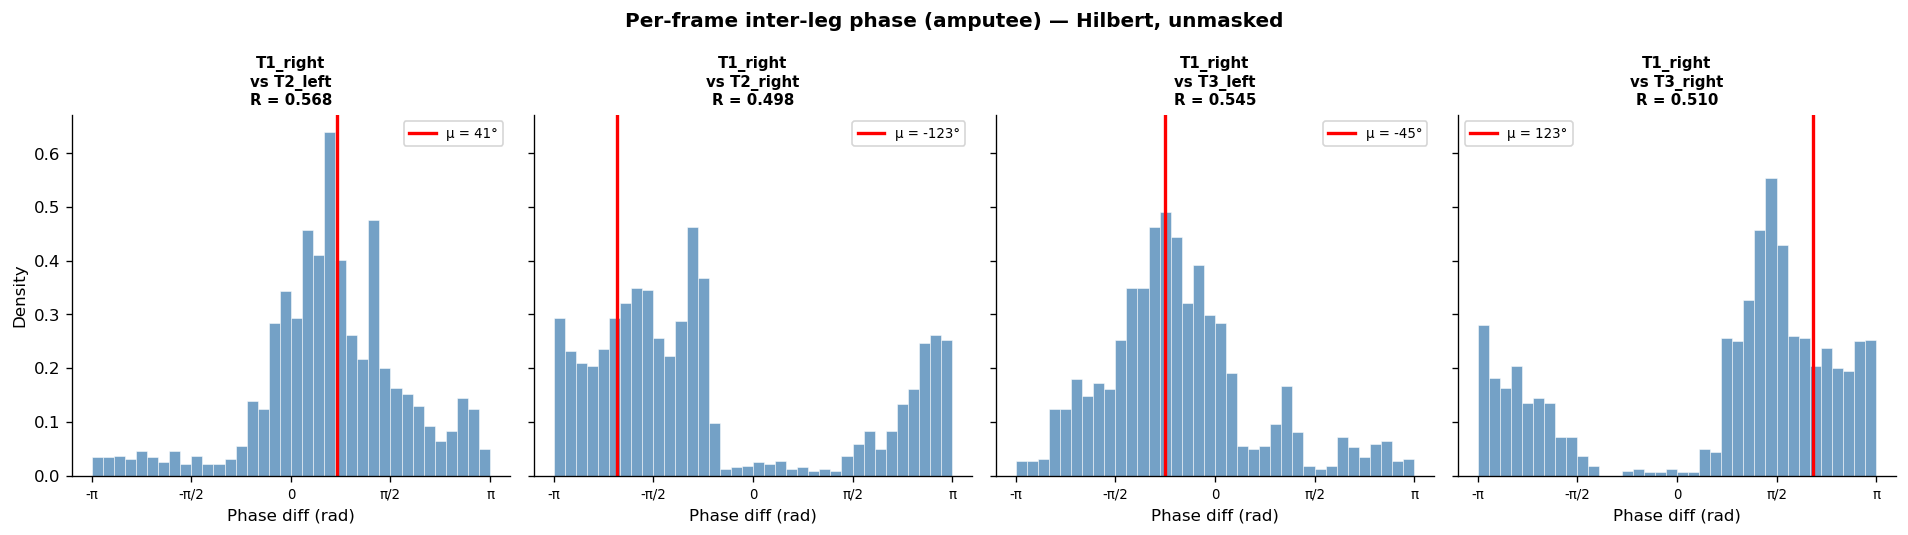

In [52]:
# Cell 8 — Inter-leg phase difference: per-frame Hilbert method (amputee)
# Uses phase_amput_raw (unmasked) so stance frames don't create NaN gaps in the diff.
ref_leg_a = CFG['ref_leg_amput']   # T1_right
other_legs = [l for l in LEGS_AMPUT if l != ref_leg_a and l in phase_amput_raw]

n_pairs = len(other_legs)
fig, axes = plt.subplots(1, n_pairs, figsize=(4 * n_pairs, 4.5), sharey=True)
if n_pairs == 1:
    axes = [axes]

for ax, lb in zip(axes, other_legs):
    ph_a = phase_amput_raw.get(ref_leg_a)
    ph_b = phase_amput_raw.get(lb)
    if ph_a is None or ph_b is None:
        ax.set_visible(False)
        continue

    diff  = (ph_a - ph_b + np.pi) % (2 * np.pi) - np.pi   # wrap → [-π, π]
    valid = np.isfinite(diff)
    phi   = diff[valid]
    print(f"{ref_leg_a} vs {lb}: {valid.sum()} valid frames out of {len(diff)}")

    if len(phi) == 0:
        ax.set_title(f'{ref_leg_a}\nvs {lb}\nNO DATA', fontsize=9, color='red')
        continue

    R  = float(np.abs(np.mean(np.exp(1j * phi))))
    mu = float(np.angle(np.mean(np.exp(1j * phi))))

    ax.hist(phi, bins=36, range=(-np.pi, np.pi), density=True,
            color='steelblue', alpha=0.75, edgecolor='white', linewidth=0.4)
    ax.axvline(mu, color='red', lw=2, label=f'μ = {np.degrees(mu):.0f}°')
    ax.set_title(f'{ref_leg_a}\nvs {lb}\nR = {R:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Phase diff (rad)')
    ax.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
    ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'], fontsize=8)
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Density')
plt.suptitle('Per-frame inter-leg phase (amputee) — Hilbert, unmasked', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3132292/3013623599.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


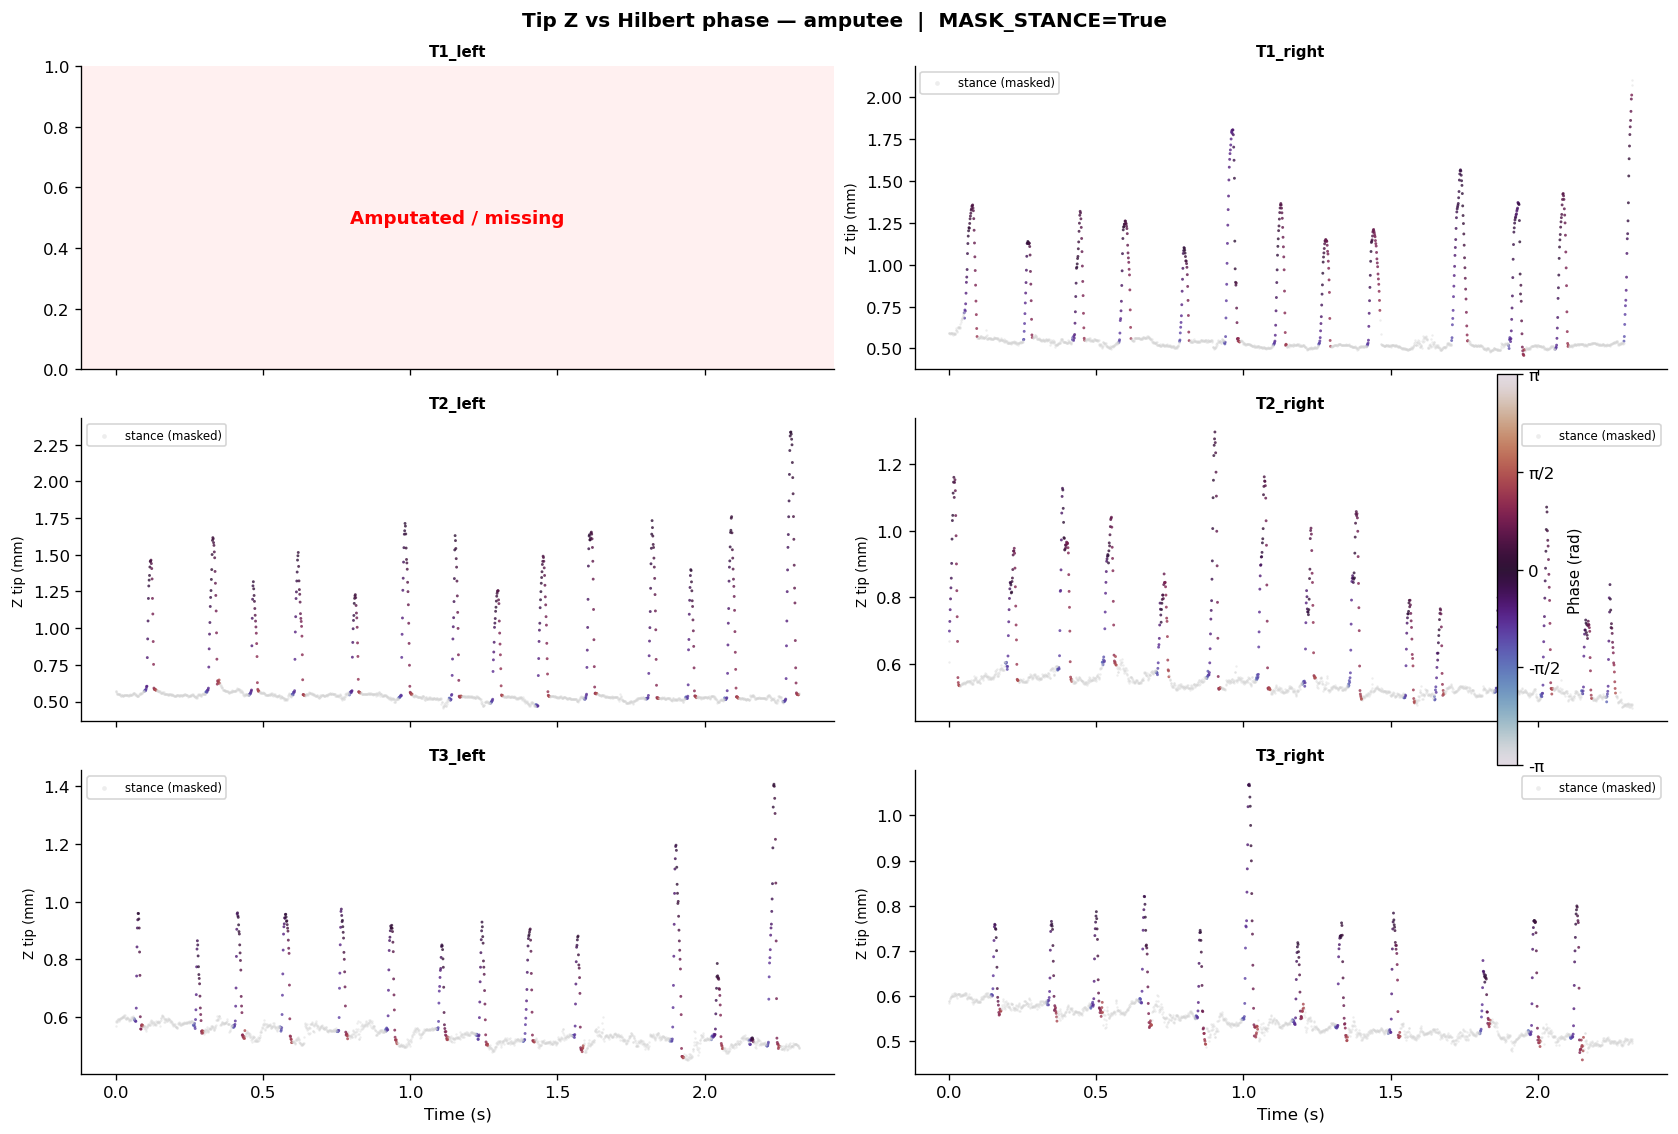

In [53]:
# Cell 8b — Tip Z vs Hilbert phase validation (amputee)
# Rows: T1L/T1R, T2L/T2R, T3L/T3R — colored by phase (twilight).
# T1L is amputated → shows label instead of data.
norm = Normalize(-np.pi, np.pi)

fig, axes = plt.subplots(len(PHASE_PAIRS), 2,
                          figsize=(14, 3.2 * len(PHASE_PAIRS)), sharex=True)

for row, (leg_l, leg_r) in enumerate(PHASE_PAIRS):
    for col, leg in enumerate([leg_l, leg_r]):
        ax = axes[row, col]

        if leg not in phase_amput or leg not in z_amput:
            ax.text(0.5, 0.5, 'Amputated / missing',
                    ha='center', va='center', transform=ax.transAxes,
                    color='red', fontsize=11, fontweight='bold')
            ax.set_facecolor('#fff0f0')
            ax.set_title(leg, fontsize=9, fontweight='bold')
            ax.spines[['top', 'right']].set_visible(False)
            continue

        z  = z_amput[leg]
        ph = phase_amput[leg]
        valid = np.isfinite(ph) & np.isfinite(z)

        ax.scatter(t_amput[valid], z[valid], c=ph[valid], cmap='twilight',
                   norm=norm, s=3, alpha=0.8, linewidths=0)
        if (~valid).any():
            ax.scatter(t_amput[~valid], z[~valid], color='lightgray',
                       s=2, alpha=0.4, linewidths=0, label='stance (masked)')
            ax.legend(fontsize=7, markerscale=2)

        ax.set_ylabel('Z tip (mm)', fontsize=8)
        ax.set_title(leg, fontsize=9, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

sm = ScalarMappable(cmap='twilight', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('Phase (rad)', fontsize=9)
cbar.set_ticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
plt.suptitle(
    f'Tip Z vs Hilbert phase — amputee  |  MASK_STANCE={CFG["MASK_STANCE"]}',
    fontweight='bold')
plt.tight_layout()
plt.show()